# 0630 2D 5-Point Gauss-Seidel filtering plots

Derived from `plot_entry_filt.0617.ipynb`; explicit per-kernel run roots, no latest-run selection.


In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATE_BASE = "20260630"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle2"
TARGET_KERNEL = "gs2d5p"
PATH_CONFIG = Path('/astrum/home/hpchzy/code/TacVar/stencil/kernel_full_paths.0630.json')

# 0630 mid-grain full runs: per host/kernel paths are patched into PATH_CONFIG as soon as each node finishes.
def load_run_root_overrides():
    if not PATH_CONFIG.exists():
        raise FileNotFoundError(f"missing path config: {PATH_CONFIG}")
    cfg = json.loads(PATH_CONFIG.read_text())
    if TARGET_KERNEL not in cfg:
        raise KeyError(f"missing TARGET_KERNEL={TARGET_KERNEL} in {PATH_CONFIG}")
    missing = [host for host in HOST_ORDER if host not in cfg[TARGET_KERNEL]]
    if missing:
        raise RuntimeError(f"missing hosts for TARGET_KERNEL={TARGET_KERNEL} in {PATH_CONFIG}: {missing}")
    roots = {}
    for host in HOST_ORDER:
        item = cfg[TARGET_KERNEL][host]
        date_base = item['date_base']
        output_root = item['output_root']
        run_id = item['run_id']
        shuffle = item.get('shuffle', SHUFFLE_SELECT)
        roots[host] = Path(f"/astrum/home/hpchzy/code/data/{date_base}/{host}/{output_root}/{run_id}/{shuffle}")
    return roots

RUN_ROOT_OVERRIDES = load_run_root_overrides()


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host not in RUN_ROOT_OVERRIDES:
        raise KeyError(f"missing explicit RUN_ROOT override for {host}")
    root = RUN_ROOT_OVERRIDES[host]
    if not root.exists():
        raise FileNotFoundError(f"missing data folder: {root}")
    return root

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#e377c2',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
    'gs2d5p': '2D 5-Point Gauss-Seidel',
    'tl_f90_cg_calc_w': 'TeaLeaf CG calc_w',
    'stream_triad': 'STREAM Triad',
    'openblas_gemm': 'OpenBLAS-style GEMM',
    'openblas_gemv': 'OpenBLAS-style GEMV',
    'openblas_dot': 'OpenBLAS-style DOT',
    'openblas_axpy': 'OpenBLAS-style AXPY',
    'hpcg_spmv': 'HPCG SpMV',
    'npb_ft_fft': 'NPB-FT FFT',
    'npb_ep': 'NPB-EP',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("target_kernel:", TARGET_KERNEL)
print("host_order:", HOST_ORDER)
print("path_config:", PATH_CONFIG)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260630/cgnr6760pn2/output_gs2d5p_filt_dsub/20260630-full-gs2d5p-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260630/camd9554n1/output_gs2d5p_filt_dsub/20260630-full-gs2d5p-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260630/c920bn3/output_gs2d5p_filt_dsub/20260630-full-gs2d5p-dsub/shuffle2
target_kernel: gs2d5p
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
path_config: /astrum/home/hpchzy/code/TacVar/stencil/kernel_full_paths.0630.json
shuffle_label: cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2


In [3]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries before filter: {len(entries)}')
entries = entries[entries['kernel'] == TARGET_KERNEL].copy()
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
if entries.empty:
    raise RuntimeError(f'No filt entries for TARGET_KERNEL={TARGET_KERNEL} in {DATA_FOLDERS}')
print(f'entries after {TARGET_KERNEL} filter: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)


entries before filter: 90
entries after gs2d5p filter: 90


,np,size,nsampRatio,nsamp,kernel,timer,host,data_folder,shuffle,filt_dir,tm_file,tr_hist_file
65,64,64,0.5,522,gs2d5p,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
71,64,64,0.5,507,gs2d5p,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
77,64,64,0.5,710,gs2d5p,papi,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
83,64,64,0.5,725,gs2d5p,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
89,64,64,0.5,522,gs2d5p,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
61,64,128,0.5,1044,gs2d5p,cgt,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
67,64,128,0.5,1029,gs2d5p,cntvcto,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
73,64,128,0.5,1232,gs2d5p,papi,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
79,64,128,0.5,1232,gs2d5p,papix6,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...
85,64,128,0.5,1044,gs2d5p,wtime,c920bn3,/astrum/home/hpchzy/code/data/20260630/c920bn3...,shuffle2,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...,/astrum/home/hpchzy/code/data/20260630/c920bn3...


# ER/EP/Wasserstein

In [4]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[df['kernel'] == TARGET_KERNEL].copy()
if df.empty:
    raise RuntimeError(f'No summary rows for TARGET_KERNEL={TARGET_KERNEL}')

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
65,c920bn3,gs2d5p,cgt,64,64,0.000000,0.008946,3.242211,0.000000,0.000000
71,c920bn3,gs2d5p,cntvcto,64,64,0.000000,0.008419,2.987940,0.000000,0.000000
77,c920bn3,gs2d5p,papi,64,64,0.010486,0.014222,7.037186,8.000362,8.000358
83,c920bn3,gs2d5p,papix6,64,64,0.003090,0.013293,6.620101,7.957266,7.957260
89,c920bn3,gs2d5p,wtime,64,64,0.000000,0.006651,2.417085,0.000000,0.000000
61,c920bn3,gs2d5p,cgt,64,128,0.000000,0.004320,3.091457,0.000000,0.000000
67,c920bn3,gs2d5p,cntvcto,64,128,0.007540,0.005621,3.982915,8.580203,8.580200
73,c920bn3,gs2d5p,papi,64,128,0.012837,0.004900,4.145729,5.858522,5.858520
79,c920bn3,gs2d5p,papix6,64,128,0.005945,0.010433,8.880402,11.128902,11.128900
85,c920bn3,gs2d5p,wtime,64,128,0.000985,0.004565,3.272362,7.155208,7.155210


In [5]:
# Size-level cross-timer divergence table, printed before plotting.
# Reference timers follow the 0630 policy: x86 -> tsc, ARM -> cntvcto.
from scipy.stats import wasserstein_distance

REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvcto'}


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Size-level TM/TR cross-timer divergence and TM->TR reduction.

    For each group, compute WD(non-ref timer, ref timer) for TM and TR,
    then aggregate non-ref timers by sum/mean. Percent columns normalize the
    mean divergence by the reference TM mean, matching the existing figure scale.
    """
    rows = []
    for gv, g in src.groupby(group_keys, sort=True):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        ref_tr = np.asarray(ref['tr_seq'], dtype=float) if ref['tr_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref_tm)
            d_tr = _wd_seq(r['tr_seq'], ref_tr)
            if np.isfinite(d_tm):
                tm_ds.append(float(d_tm))
            if np.isfinite(d_tr):
                tr_ds.append(float(d_tr))
        tm_sum = float(np.sum(tm_ds)) if tm_ds else np.nan
        tr_sum = float(np.sum(tr_ds)) if tr_ds else np.nan
        tm_mean = float(np.mean(tm_ds)) if tm_ds else np.nan
        tr_mean = float(np.mean(tr_ds)) if tr_ds else np.nan
        reduction = (tm_sum - tr_sum) / tm_sum if (np.isfinite(tm_sum) and tm_sum > 0) else np.nan
        if np.isfinite(base) and base > 0:
            tm_pct = 100.0 * tm_mean / base if np.isfinite(tm_mean) else np.nan
            tr_pct = 100.0 * tr_mean / base if np.isfinite(tr_mean) else np.nan
            d_before = tm_mean / base if np.isfinite(tm_mean) else np.nan
            d_after = tr_mean / base if np.isfinite(tr_mean) else np.nan
        else:
            tm_pct = tr_pct = d_before = d_after = np.nan
        rows.append({
            **gd,
            'ref_timer': ref_timer,
            'n_timer': len(tm_ds),
            'tm_div_sum_ns': tm_sum,
            'tr_div_sum_ns': tr_sum,
            'tm_div_mean_ns': tm_mean,
            'tr_div_mean_ns': tr_mean,
            'tm_div_pct_ref': tm_pct,
            'tr_div_pct_ref': tr_pct,
            'reduction': reduction,
            # Compatibility with the existing WD/divergence figure cell.
            'd_before': d_before,
            'd_after': d_after,
        })
    cols = [
        'kernel', 'host', 'np', 'size', 'nsampRatio', 'ref_timer', 'n_timer',
        'tm_div_sum_ns', 'tr_div_sum_ns', 'tm_div_mean_ns', 'tr_div_mean_ns',
        'tm_div_pct_ref', 'tr_div_pct_ref', 'reduction', 'd_before', 'd_after',
    ]
    return pd.DataFrame(rows).reindex(columns=cols)


div_size_df = divergence_table(df, ['kernel', 'host', 'np', 'size', 'nsampRatio'])
div_df = div_size_df.copy()

print(f'[SIZE DIVERGENCE] kernel={TARGET_KERNEL} {SHUFFLE_LABEL}')
_print_cols = [
    'kernel', 'host', 'np', 'size', 'nsampRatio', 'ref_timer', 'n_timer',
    'tm_div_sum_ns', 'tr_div_sum_ns', 'tm_div_mean_ns', 'tr_div_mean_ns',
    'tm_div_pct_ref', 'tr_div_pct_ref', 'reduction',
]
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
    print(div_size_df[_print_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_string(index=False))

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    div_csv = OUT_DIR / f'{TARGET_KERNEL}_{SHUFFLE_LABEL}_size_divergence.csv'
    div_size_df[_print_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_csv(div_csv, index=False)
    print(div_csv)


[SIZE DIVERGENCE] kernel=gs2d5p cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2
kernel        host  np  size  nsampRatio ref_timer  n_timer  tm_div_sum_ns  tr_div_sum_ns  tm_div_mean_ns  tr_div_mean_ns  tm_div_pct_ref  tr_div_pct_ref  reduction
gs2d5p     c920bn3  64    64         0.5   cntvcto        4     310.604547      11.368330       77.651137        2.842082       21.842795        0.799461   0.963399
gs2d5p     c920bn3  64   128         0.5   cntvcto        4     289.821824      14.275571       72.455456        3.568893       10.153793        0.500139   0.950744
gs2d5p     c920bn3  64   256         0.5   cntvcto        4     307.852967       8.399108       76.963242        2.099777        5.437177        0.148342   0.972717
gs2d5p     c920bn3  64   512         0.5   cntvcto        4     311.403987      52.390912       77.850997       13.097728        2.748413        0.462396   0.831759
gs2d5p     c920bn3  64  1024         0.5   cntvcto        4     365.976699     168.29

In [6]:
# Generic cross-timer spread table: (max(timer median) - min(timer median)) / median(timer medians).
# This is intentionally separate from the Wasserstein div_size_df above.

def _finite_median(seq):
    arr = np.asarray(seq, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.median(arr)) if arr.size else np.nan


def generic_timer_spread_table(src, group_keys):
    rows = []
    for gv, g in src.groupby(group_keys, sort=True):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        timer_rows = []
        for _, r in g.iterrows():
            tm_med = _finite_median(r['tm_seq'])
            tr_med = _finite_median(r['tr_seq'])
            if np.isfinite(tm_med) and np.isfinite(tr_med):
                timer_rows.append({'timer': r['timer'], 'tm_median_ns': tm_med, 'tr_median_ns': tr_med})
        if len(timer_rows) < 2:
            continue
        td = pd.DataFrame(timer_rows)
        tm_vals = td['tm_median_ns'].to_numpy(dtype=float)
        tr_vals = td['tr_median_ns'].to_numpy(dtype=float)
        tm_center = float(np.median(tm_vals))
        tr_center = float(np.median(tr_vals))
        tm_spread = (float(np.max(tm_vals)) - float(np.min(tm_vals))) / tm_center if tm_center > 0 else np.nan
        tr_spread = (float(np.max(tr_vals)) - float(np.min(tr_vals))) / tr_center if tr_center > 0 else np.nan
        tm_min_idx = int(td['tm_median_ns'].idxmin())
        tm_max_idx = int(td['tm_median_ns'].idxmax())
        tr_min_idx = int(td['tr_median_ns'].idxmin())
        tr_max_idx = int(td['tr_median_ns'].idxmax())
        rows.append({
            **gd,
            'n_timer': int(len(td)),
            'tm_median_center_ns': tm_center,
            'tr_median_center_ns': tr_center,
            'tm_min_ns': float(np.min(tm_vals)),
            'tm_max_ns': float(np.max(tm_vals)),
            'tr_min_ns': float(np.min(tr_vals)),
            'tr_max_ns': float(np.max(tr_vals)),
            'tm_spread_pct': 100.0 * tm_spread if np.isfinite(tm_spread) else np.nan,
            'tr_spread_pct': 100.0 * tr_spread if np.isfinite(tr_spread) else np.nan,
            'spread_delta_pct': 100.0 * (tr_spread - tm_spread) if (np.isfinite(tm_spread) and np.isfinite(tr_spread)) else np.nan,
            'spread_reduction_pct': 100.0 * (tm_spread - tr_spread) / tm_spread if (np.isfinite(tm_spread) and tm_spread > 0 and np.isfinite(tr_spread)) else np.nan,
            'tm_min_timer': td.loc[tm_min_idx, 'timer'],
            'tm_max_timer': td.loc[tm_max_idx, 'timer'],
            'tr_min_timer': td.loc[tr_min_idx, 'timer'],
            'tr_max_timer': td.loc[tr_max_idx, 'timer'],
        })
    cols = [
        'kernel', 'host', 'np', 'size', 'nsampRatio', 'n_timer',
        'tm_median_center_ns', 'tr_median_center_ns',
        'tm_min_ns', 'tm_max_ns', 'tr_min_ns', 'tr_max_ns',
        'tm_spread_pct', 'tr_spread_pct', 'spread_delta_pct', 'spread_reduction_pct',
        'tm_min_timer', 'tm_max_timer', 'tr_min_timer', 'tr_max_timer',
    ]
    return pd.DataFrame(rows).reindex(columns=cols)


generic_spread_df = generic_timer_spread_table(df, ['kernel', 'host', 'np', 'size', 'nsampRatio'])
_generic_cols = [
    'kernel', 'host', 'np', 'size', 'nsampRatio', 'n_timer',
    'tm_spread_pct', 'tr_spread_pct', 'spread_delta_pct', 'spread_reduction_pct',
    'tm_min_timer', 'tm_max_timer', 'tr_min_timer', 'tr_max_timer',
]
print(f'[GENERIC TIMER SPREAD] kernel={TARGET_KERNEL} {SHUFFLE_LABEL}')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 220):
    print(generic_spread_df[_generic_cols].sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_string(index=False))

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    generic_csv = OUT_DIR / f'{TARGET_KERNEL}_{SHUFFLE_LABEL}_generic_timer_spread.csv'
    generic_spread_df.sort_values(['kernel', 'host', 'np', 'size', 'nsampRatio']).to_csv(generic_csv, index=False)
    print(generic_csv)


[GENERIC TIMER SPREAD] kernel=gs2d5p cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2
kernel        host  np  size  nsampRatio  n_timer  tm_spread_pct  tr_spread_pct  spread_delta_pct  spread_reduction_pct tm_min_timer tm_max_timer tr_min_timer tr_max_timer
gs2d5p     c920bn3  64    64         0.5        5      40.443705       0.779863        -39.663842             98.071732      cntvcto       papix6       papix6         papi
gs2d5p     c920bn3  64   128         0.5        5      19.598717       1.437974        -18.160743             92.662920      cntvcto       papix6          cgt       papix6
gs2d5p     c920bn3  64   256         0.5        5      10.406793       0.153727        -10.253066             98.522824      cntvcto       papix6       papix6          cgt
gs2d5p     c920bn3  64   512         0.5        5       5.017571       0.548517         -4.469054             89.068074      cntvcto       papix6        wtime      cntvcto
gs2d5p     c920bn3  64  1024         0.5     

In [7]:
print(df['kernel'].unique())
df.query('np==64 and nsampRatio==0.5 and kernel=="jacobi2d5p" and host=="camd9554n1"')
for k,v in df.groupby(['np','nsampRatio','shuffle','kernel','host']):
    print(k)
    v['tm_median'] = v['tm_seq'].apply(np.median)
    print(v.columns)
    print(v[['kernel','size','host','tm_median']])

['gs2d5p']
(np.int64(64), np.float64(0.5), 'shuffle2', 'gs2d5p', 'c920bn3')
Index(['np', 'size', 'nsampRatio', 'nsamp', 'kernel', 'timer', 'host',
       'data_folder', 'shuffle', 'filt_dir', 'tm_file', 'tr_hist_file', 'ep',
       'er', 'wd', 'tm_wd', 'tr_wd', 'tr_seq', 'tm_seq', 'tm_median'],
      dtype='object')
    kernel  size     host     tm_median
65  gs2d5p    64  c920bn3    366.000000
71  gs2d5p    64  c920bn3    355.500000
77  gs2d5p    64  c920bn3    496.062418
83  gs2d5p    64  c920bn3    503.523959
89  gs2d5p    64  c920bn3    365.500000
61  gs2d5p   128  c920bn3    716.000000
67  gs2d5p   128  c920bn3    714.172632
73  gs2d5p   128  c920bn3    851.465424
79  gs2d5p   128  c920bn3    855.677737
85  gs2d5p   128  c920bn3    722.012083
63  gs2d5p   256  c920bn3   1426.000000
69  gs2d5p   256  c920bn3   1415.500000
75  gs2d5p   256  c920bn3   1554.867807
81  gs2d5p   256  c920bn3   1563.900864
87  gs2d5p   256  c920bn3   1425.500000
64  gs2d5p   512  c920bn3   2840.813647
70

In [8]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

[WD / divergence Tm->Tr + eps]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvcto'}
kernel=gs2d5p h ost=cgnr6760pn2  before: [np.float64(36.071197471751724), np.float64(18.10711855409588), np.float64(9.236310000478305), np.float64(4.850055969068249), np.float64(2.563618476271606), np.float64(4.545981941190349)]  after: [np.float64(1.1150960652372972), np.float64(0.7783333321344302), np.float64(0.40932408904007295), np.float64(0.2760872058399331), np.float64(0.31903708402648295), np.float64(8.987689446140184)]


kernel=gs2d5p h ost=camd9554n1  before: [np.float64(159.91147294437116), np.float64(79.79388412453847), np.float64(40.917505417182866), np.float64(20.786101117127913), np.float64(8.208376928127977), np.float64(1.9571063889905354)]  after: [np.float64(5.014396949731671), np.float64(1.4900481184749617), np.float64(0.6555766132290543), np.float64(0.6062097878562697), np.float64(0.9233031838187744), np.float64(5.347946765469019)]


kernel=gs2d5p h ost=c920bn3  before: [np.float64(21.842795163542178), np.float64(10.153792907688748), np.float64(5.437177095300492), np.float64(2.7484127141276242), np.float64(1.5968400837716359), np.float64(1.1313817254934804)]  after: [np.float64(0.799460604953222), np.float64(0.5001389662342267), np.float64(0.14834171369977844), np.float64(0.46239564790471627), np.float64(0.7342930186854398), np.float64(0.9678946892728921)]


/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_wd_div_eper_by_host.png


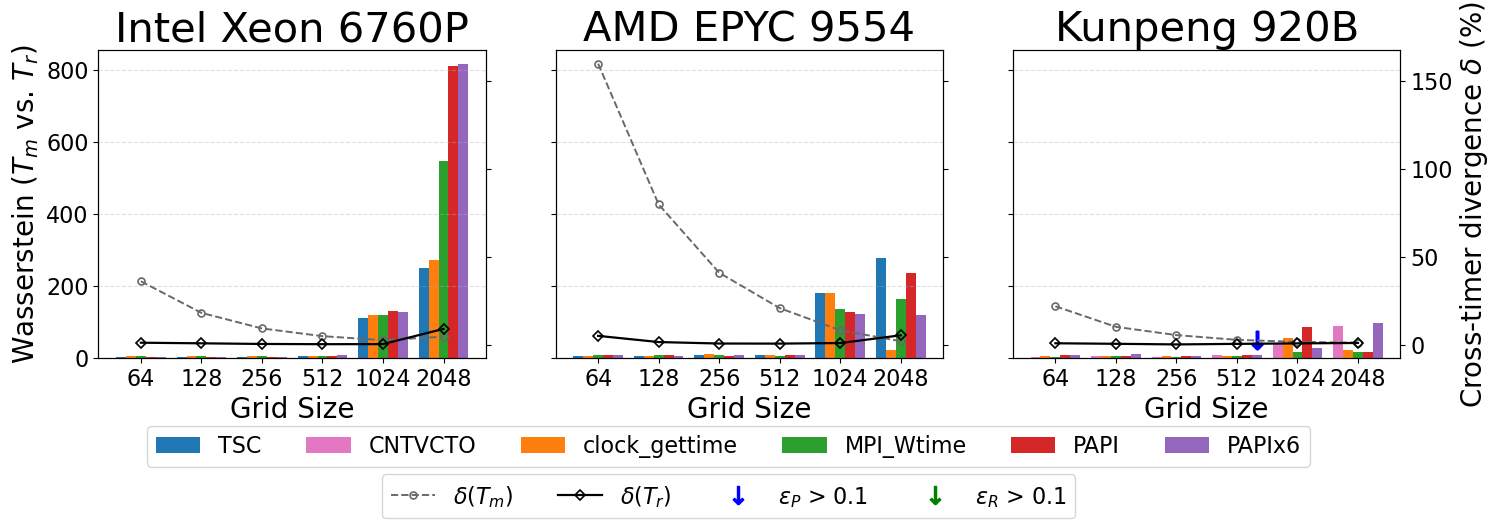

In [9]:
# Cross-timer divergence before (T_m) / after (T_r) + ep/er threshold indicators (stencil)
# Reuse div_size_df/div_df computed and printed in the previous cell.
from matplotlib.lines import Line2D

if 'div_size_df' not in globals() or div_size_df.empty:
    raise RuntimeError('div_size_df is missing or empty; run the size-level divergence cell before plotting')
div_df = div_size_df.copy()

# ---- thresholds (tune by hand) ----
EP_THRESHOLD = 0.1  # eps_P over this -> flag
ER_THRESHOLD = 0.1  # eps_R over this -> flag

# ---- fonts (tune by hand) ----
TITLE_FONTSIZE = 30
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
ARROW_FONTSIZE = 13
# legend vertical offsets (more negative = lower); timer legend above, divergence legend below
TIMER_LEGEND_Y = 0.07
DIV_LEGEND_Y = -0.04


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Cross-timer divergence before (TM) and after (TR), plus deviation reduction ratio.
    delta = mean over non-ref timers of WD(timer, ref) / mean(ref measured time); same base
    for before/after so the two levels are comparable. reduction = (sum_tm - sum_tr)/sum_tm."""
    rows = []
    for gv, g in src.groupby(group_keys):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref['tm_seq'])
            d_tr = _wd_seq(r['tr_seq'], ref['tr_seq'])
            if np.isfinite(d_tm):
                tm_ds.append(d_tm)
            if np.isfinite(d_tr):
                tr_ds.append(d_tr)
        s_tm = float(np.sum(tm_ds)) if tm_ds else np.nan
        s_tr = float(np.sum(tr_ds)) if tr_ds else np.nan
        gd['reduction'] = (s_tm - s_tr) / s_tm if (np.isfinite(s_tm) and s_tm > 0) else np.nan
        if gd['reduction'] is np.nan:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")
        if int(gd['size']) == 256:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")

        if np.isfinite(base) and base > 0:
            gd['d_before'] = (np.mean(tm_ds) / base) if tm_ds else np.nan
            gd['d_after'] = (np.mean(tr_ds) / base) if tr_ds else np.nan
        else:
            gd['d_before'] = gd['d_after'] = np.nan
        rows.append(gd)
    return pd.DataFrame(rows)


def _flag_color(ep_v, er_v):
    ep_hi = np.isfinite(ep_v) and ep_v > EP_THRESHOLD
    er_hi = np.isfinite(er_v) and er_v > ER_THRESHOLD
    if ep_hi and er_hi:
        return 'red'
    if ep_hi:
        return 'blue'
    if er_hi:
        return 'green'
    return None


metric_bar = 'wd'

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue
    dk = div_df[div_df['kernel'] == kernel]
    kernel_label = kernel_df['kernel_label'].iloc[0]
    refs = {HOST_LABELS.get(h, h): REF_TIMER_BY_HOST.get(h) for h in hosts}
    print(f'[WD / divergence Tm->Tr + eps]  kernel={kernel_label}  {SHUFFLE_LABEL}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}  ref_by_host={refs}')

    gmax = np.nanmax(kernel_df[metric_bar].to_numpy(dtype=float)) if len(kernel_df) else 1.0
    if not np.isfinite(gmax) or gmax <= 0:
        gmax = 1.0
    arrow_dy = 0.05 * gmax

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.6 * len(hosts), 4.4), sharey=True, constrained_layout=False)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    bar_handles = {}          # keyed by timer -> handle, for ordered legend
    before_handle = after_handle = None
    any_red = False
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        ref_timer = REF_TIMER_BY_HOST.get(host)
        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid Size', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.set_ylabel(r'Wasserstein ($T_m$ vs. $T_r$)' if ax1 is axes[0] else '', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)
        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            heights = sub[metric_bar].to_numpy(dtype=float)
            b = ax1.bar(x + offset, heights, width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))
            bar_handles.setdefault(timer, b)
            ep_arr = sub['ep'].to_numpy(dtype=float)
            er_arr = sub['er'].to_numpy(dtype=float)
            for j in range(len(size_order)):
                h = heights[j]
                if not np.isfinite(h):
                    continue
                c = _flag_color(ep_arr[j], er_arr[j])
                if c is None:
                    continue
                if c == 'red':
                    any_red = True
                ax1.plot(x[j] + offset, h + arrow_dy, marker=r'$\downarrow$', linestyle='None',
                         color=c, markersize=ARROW_FONTSIZE, markeredgewidth=1.4, zorder=6, clip_on=False)

        # x ticks: horizontal, with the ref timer's (tsc/cntvct) TM p25/p75 on a second line
        xticklabels = []
        for s in size_order:
            rr = host_df[(host_df['timer'] == ref_timer) & (host_df['size'] == int(s))]
            if len(rr) and rr.iloc[0]['tm_seq'] is not None:
                seq = np.asarray(rr.iloc[0]['tm_seq'], dtype=float)
                p25, p75 = np.quantile(seq, 0.25), np.quantile(seq, 0.75)
                # xticklabels.append(f'{s}\n({p25:.0f}/{p75:.0f})')
                xticklabels.append(f'{s}')
            else:
                xticklabels.append(f'{s}')
        ax1.set_xticks(x)
        ax1.set_xticklabels(xticklabels, rotation=0, fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)

        dh = dk[dk['host'] == host]
        db = dh.groupby('size')['d_before'].mean()
        da = dh.groupby('size')['d_after'].mean()
        before_vals = [100.0 * db.get(int(s), np.nan) for s in size_order]
        after_vals = [100.0 * da.get(int(s), np.nan) for s in size_order]
        lb, = ax2.plot(x, before_vals, marker='o', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='dimgray', linestyle='--', linewidth=1.4)
        la, = ax2.plot(x, after_vals, marker='D', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='black', linestyle='-', linewidth=1.6)

        print(f"kernel={kernel} h ost={host}  before: {before_vals}  after: {after_vals}")

        before_handle, after_handle = lb, la
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    left_lims = [ax.get_ylim() for ax in axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    rlims = [ax.get_ylim() for ax in right_axes]
    rylim = (min(lo for lo, hi in rlims), max(hi for lo, hi in rlims))
    for j, ax in enumerate(right_axes):
        ax.set_ylim(rylim)
        if j == len(right_axes) - 1:
            ax.set_ylabel(r'Cross-timer divergence $\delta$ (%)', fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax.set_yticklabels([])

    # timer legend (ordered by timer_sort_key), placed at the bottom
    ordered_timers = sorted(bar_handles, key=timer_sort_key)
    fig.legend([bar_handles[t] for t in ordered_timers], [timer_label(t) for t in ordered_timers],
               ncol=min(6, max(1, len(ordered_timers))), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, TIMER_LEGEND_Y), frameon=True)

    # divergence legend (below the timer legend): delta lines + eps arrows (+both only if drawn)
    arrow_proxies = [
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='blue', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_P$ > {EP_THRESHOLD:g}'),
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='green', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_R$ > {ER_THRESHOLD:g}'),
    ]
    if any_red:
        arrow_proxies.append(Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='red', markersize=ARROW_FONTSIZE, label='both'))
    div_handles = [before_handle, after_handle] + arrow_proxies
    div_labels = [r'$\delta(T_m)$', r'$\delta(T_r)$'] + [p.get_label() for p in arrow_proxies]
    fig.legend(div_handles, div_labels, ncol=min(5, len(div_labels)), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, DIV_LEGEND_Y), frameon=True)

    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.18)

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_wd_div_eper_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()

In [10]:
tmp_df = df.join(div_df, lsuffix="_left", rsuffix="_right",how='left').sort_values(['reduction'],ascending=False)[['host_left','size_left','kernel_left','ep','er','reduction']]
tmp_df[tmp_df['size_left'] == 256]

,host_left,size_left,kernel_left,ep,er,reduction
9,cgnr6760pn2,256,gs2d5p,0.039630,0.002149,0.970836
15,cgnr6760pn2,256,gs2d5p,0.003870,0.002333,0.943075
3,cgnr6760pn2,256,gs2d5p,0.000000,0.005179,0.831759
63,c920bn3,256,gs2d5p,0.000000,0.004040,NaN
69,c920bn3,256,gs2d5p,0.000000,0.001883,NaN
75,c920bn3,256,gs2d5p,0.013972,0.003562,NaN
81,c920bn3,256,gs2d5p,0.006943,0.002704,NaN
87,c920bn3,256,gs2d5p,0.000000,0.002006,NaN
33,camd9554n1,256,gs2d5p,0.000192,0.012929,NaN
39,camd9554n1,256,gs2d5p,0.000006,0.004095,NaN


In [11]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  2D 5-Point Gauss-Seidel (gs2d5p): [64, 128, 256, 1024, 2048]


# Filt Plot

In [12]:
entries['nsamp'].unique()

array([ 4304,   531, 10148,  1044,  2073,   273,  4471,   709,  8839,
        1224,  2252,   452,  4536,   719,  9008,  1234,  2263,   463,
        4293,   527, 10226,  1041,  2068,   267,  4307,   533,  9490,
        1045,  2075,   275,  4905,   604, 11704,  1179,  2328,   310,
        5649,  1536, 11628,  2111,  3275,  1241,  1551, 11595,  2126,
        3290,  1257,  4873,   589,  1164,  4888, 11735,  1178,  8208,
       16400,  2059,  4118,   522,  8192,  1029, 16385,  2044,  4103,
         507,  8396,  1232, 16618,  2247,  4306,   710,  8411, 16632,
        2262,   725])

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=64  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=246.00 ns  tr_median=213.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=252.50 ns  tr_median=214.50 ns
host=cgnr6760pn2 timer=wtime  tm_median=254.00 ns  tr_median=216.00 ns
host=cgnr6760pn2 timer=papi  tm_median=411.39 ns  tr_median=209.39 ns
host=cgnr6760pn2 timer=papix6  tm_median=421.65 ns  tr_median=211.65 ns
host=camd9554n1 timer=tsc  tm_median=195.50 ns  tr_median=175.50 ns
host=camd9554n1 timer=cgt  tm_median=204.53 ns  tr_median=184.53 ns
host=camd9554n1 timer=wtime  tm_median=205.50 ns  tr_median=186.50 ns
host=camd9554n1 timer=papi  tm_median=806.40 ns  tr_median=184.40 ns
host=camd9554n1 timer=papix6  tm_median=816.11 ns  tr_median=185.11 ns
host=c920bn3 timer=cntvcto  tm_median=355.50 ns  tr_median=325.50 ns
host=c920bn3 timer=cgt  tm_median

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size64_ratio0.5_tm_tr_by_host.png


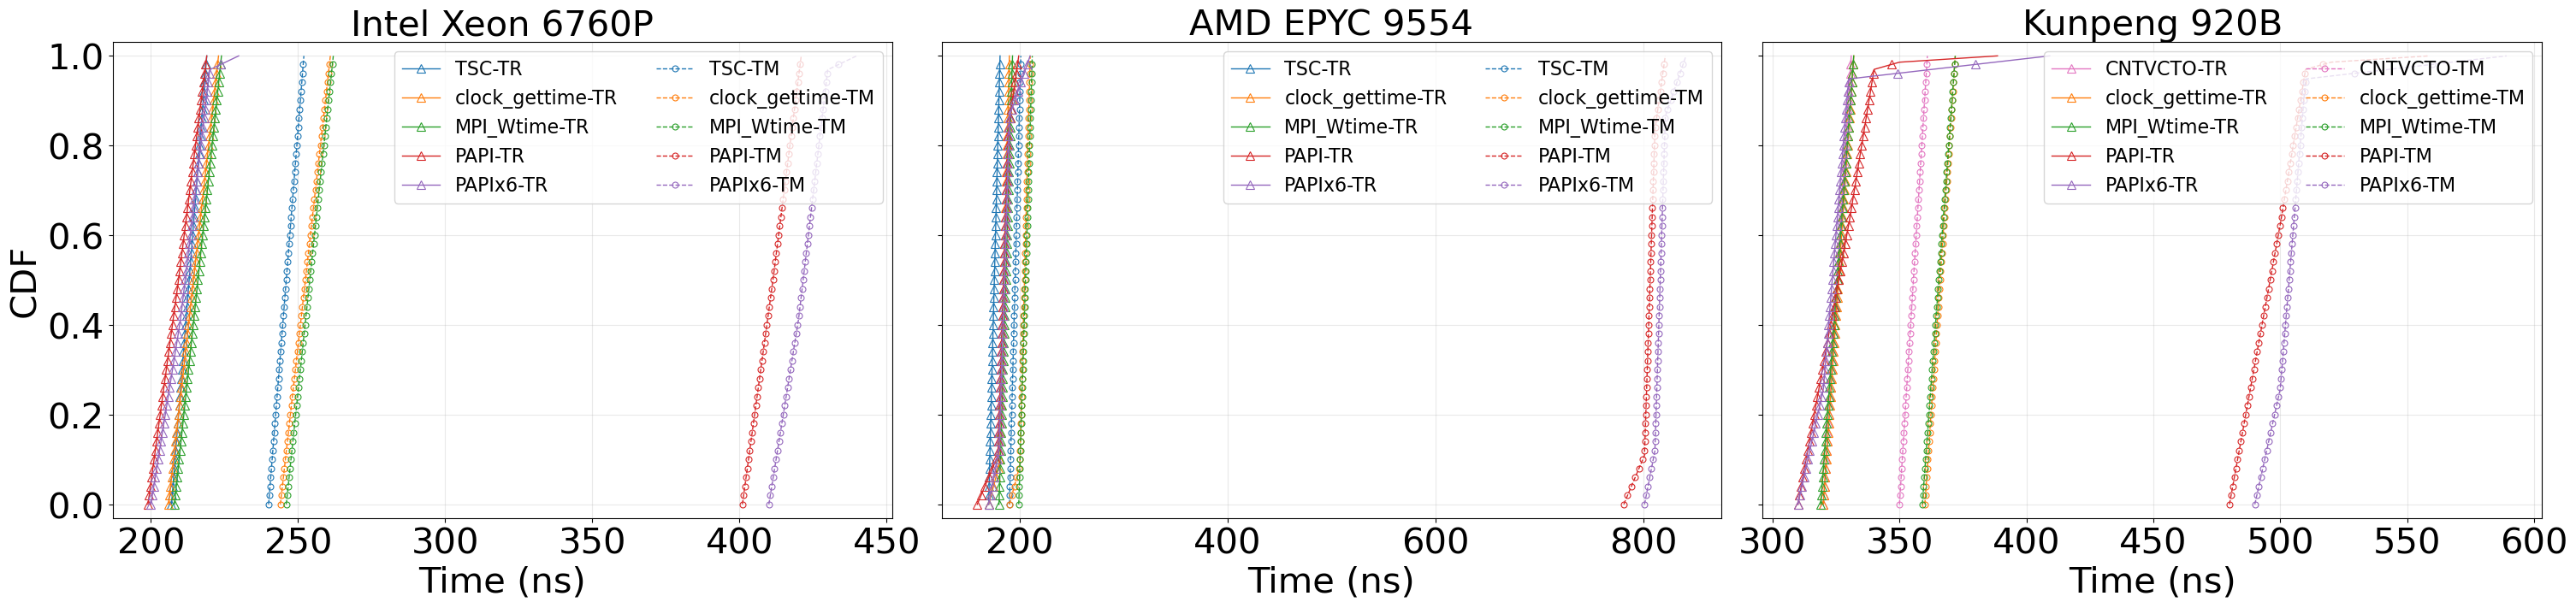

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=128  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=481.00 ns  tr_median=448.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=486.00 ns  tr_median=447.00 ns
host=cgnr6760pn2 timer=wtime  tm_median=488.00 ns  tr_median=448.00 ns
host=cgnr6760pn2 timer=papi  tm_median=645.05 ns  tr_median=442.05 ns
host=cgnr6760pn2 timer=papix6  tm_median=654.32 ns  tr_median=442.32 ns
host=camd9554n1 timer=tsc  tm_median=385.50 ns  tr_median=365.50 ns
host=camd9554n1 timer=cgt  tm_median=390.50 ns  tr_median=359.50 ns
host=camd9554n1 timer=wtime  tm_median=392.36 ns  tr_median=362.36 ns
host=camd9554n1 timer=papi  tm_median=992.46 ns  tr_median=370.46 ns
host=camd9554n1 timer=papix6  tm_median=1002.20 ns  tr_median=371.20 ns
host=c920bn3 timer=cntvcto  tm_median=714.17 ns  tr_median=674.17 ns
host=c920bn3 timer=cgt  tm_medi

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size128_ratio0.5_tm_tr_by_host.png


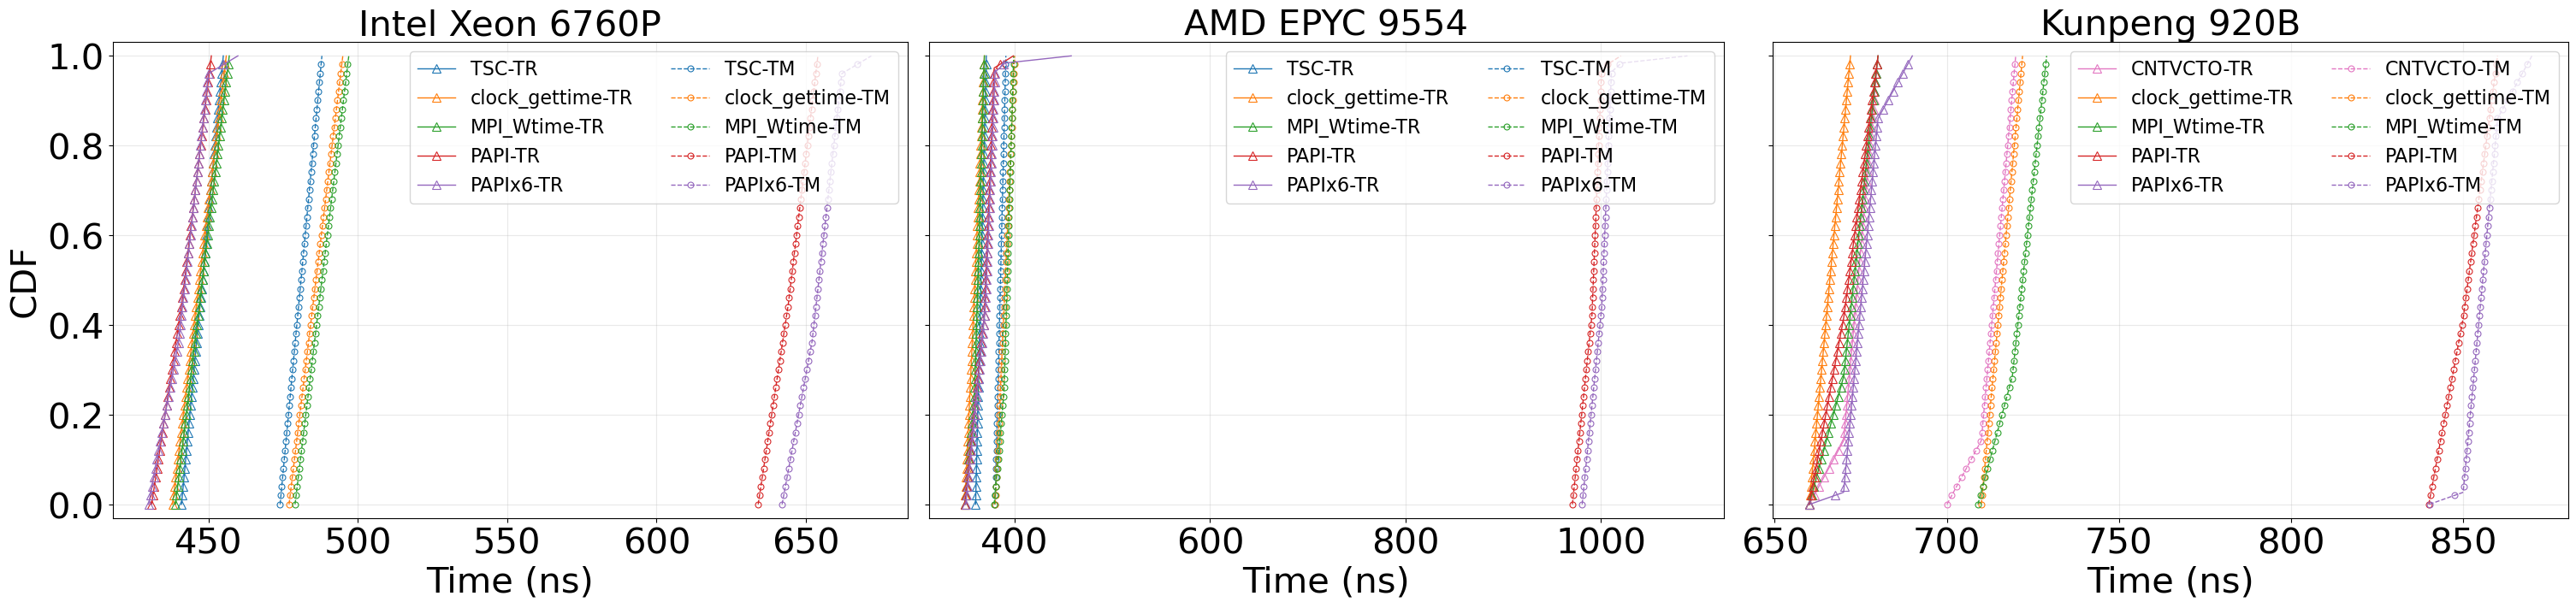

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=947.00 ns  tr_median=912.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=953.00 ns  tr_median=913.00 ns
host=cgnr6760pn2 timer=wtime  tm_median=953.50 ns  tr_median=913.50 ns
host=cgnr6760pn2 timer=papi  tm_median=1111.43 ns  tr_median=905.43 ns
host=cgnr6760pn2 timer=papix6  tm_median=1121.24 ns  tr_median=907.24 ns
host=camd9554n1 timer=tsc  tm_median=757.85 ns  tr_median=737.85 ns
host=camd9554n1 timer=cgt  tm_median=766.65 ns  tr_median=736.65 ns
host=camd9554n1 timer=wtime  tm_median=764.62 ns  tr_median=733.62 ns
host=camd9554n1 timer=papi  tm_median=1367.92 ns  tr_median=737.92 ns
host=camd9554n1 timer=papix6  tm_median=1376.67 ns  tr_median=745.67 ns
host=c920bn3 timer=cntvcto  tm_median=1415.50 ns  tr_median=1365.50 ns
host=c920bn3 timer=cgt  tm

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size256_ratio0.5_tm_tr_by_host.png


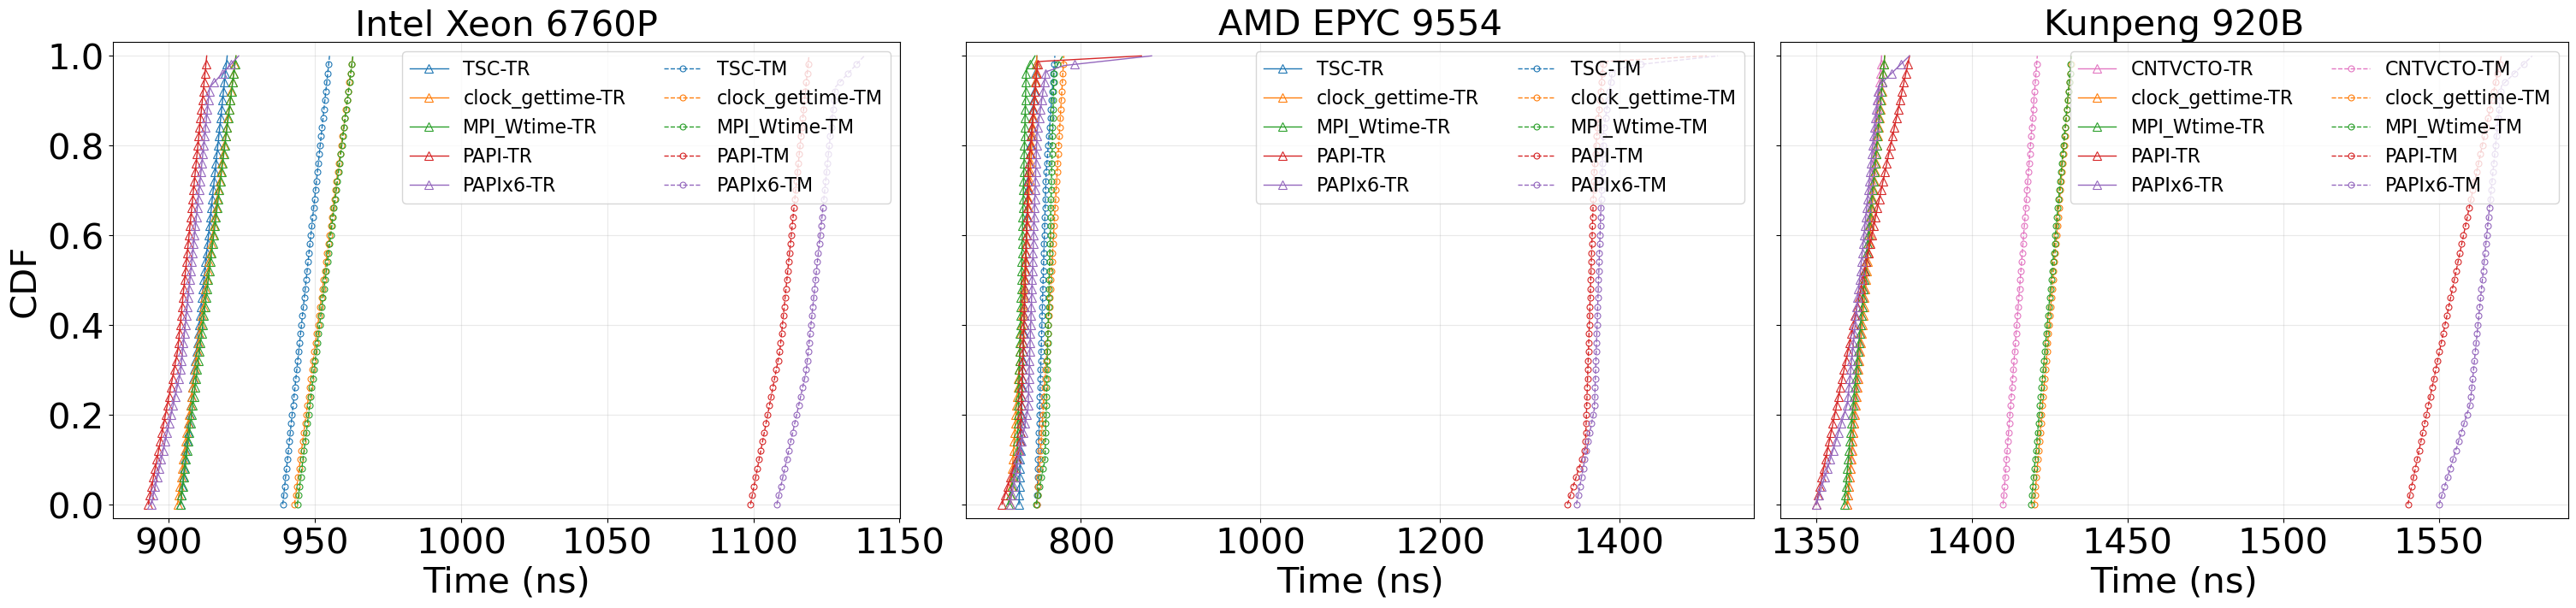

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=512  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=1876.35 ns  tr_median=1835.51 ns
host=cgnr6760pn2 timer=cgt  tm_median=1882.11 ns  tr_median=1836.87 ns
host=cgnr6760pn2 timer=wtime  tm_median=1884.94 ns  tr_median=1839.40 ns
host=cgnr6760pn2 timer=papi  tm_median=2044.57 ns  tr_median=1833.71 ns
host=cgnr6760pn2 timer=papix6  tm_median=2054.45 ns  tr_median=1835.31 ns
host=camd9554n1 timer=tsc  tm_median=1504.19 ns  tr_median=1480.70 ns
host=camd9554n1 timer=cgt  tm_median=1507.48 ns  tr_median=1476.42 ns
host=camd9554n1 timer=wtime  tm_median=1508.42 ns  tr_median=1469.42 ns
host=camd9554n1 timer=papi  tm_median=2115.75 ns  tr_median=1484.75 ns
host=camd9554n1 timer=papix6  tm_median=2125.65 ns  tr_median=1494.65 ns
host=c920bn3 timer=cntvcto  tm_median=2833.25 ns  tr_median=2763.25 ns
host=c920b

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size512_ratio0.5_tm_tr_by_host.png


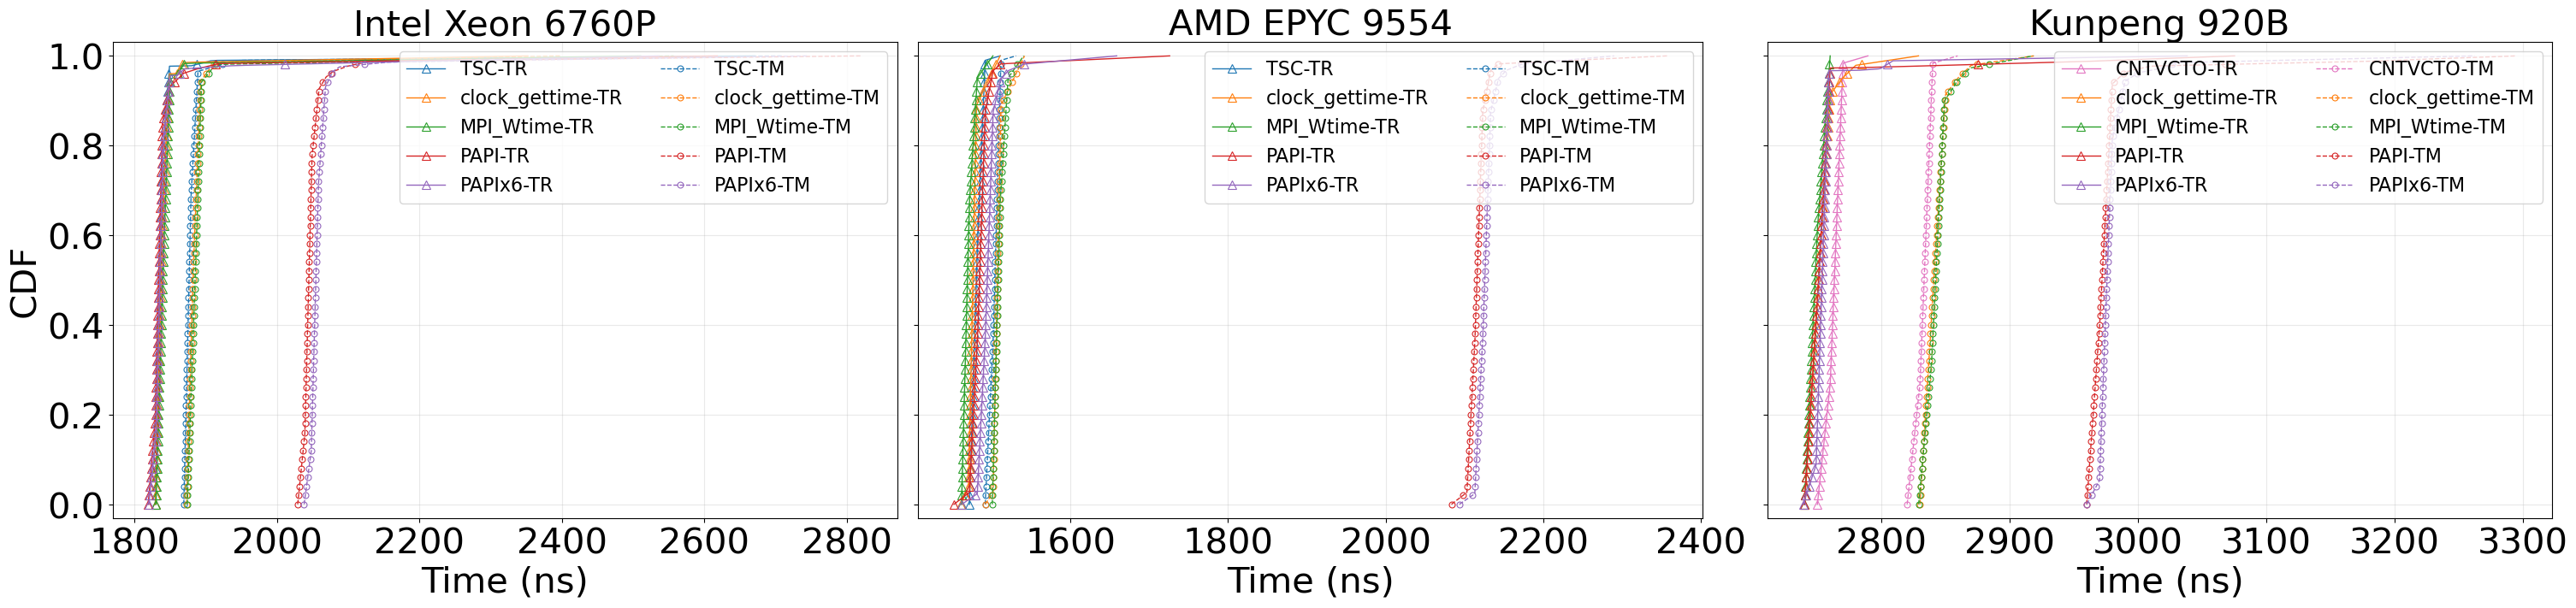

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=1024  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=3895.57 ns  tr_median=3775.79 ns
host=cgnr6760pn2 timer=cgt  tm_median=3904.53 ns  tr_median=3774.70 ns
host=cgnr6760pn2 timer=wtime  tm_median=3908.12 ns  tr_median=3777.26 ns
host=cgnr6760pn2 timer=papi  tm_median=4056.76 ns  tr_median=3746.40 ns
host=cgnr6760pn2 timer=papix6  tm_median=4115.50 ns  tr_median=3804.70 ns
host=camd9554n1 timer=tsc  tm_median=3150.28 ns  tr_median=3033.12 ns
host=camd9554n1 timer=cgt  tm_median=3166.79 ns  tr_median=3027.34 ns
host=camd9554n1 timer=wtime  tm_median=3156.89 ns  tr_median=3054.85 ns
host=camd9554n1 timer=papi  tm_median=3645.91 ns  tr_median=2973.69 ns
host=camd9554n1 timer=papix6  tm_median=3645.11 ns  tr_median=2979.78 ns
host=c920bn3 timer=cntvcto  tm_median=5657.76 ns  tr_median=5527.78 ns
host=c920

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size1024_ratio0.5_tm_tr_by_host.png


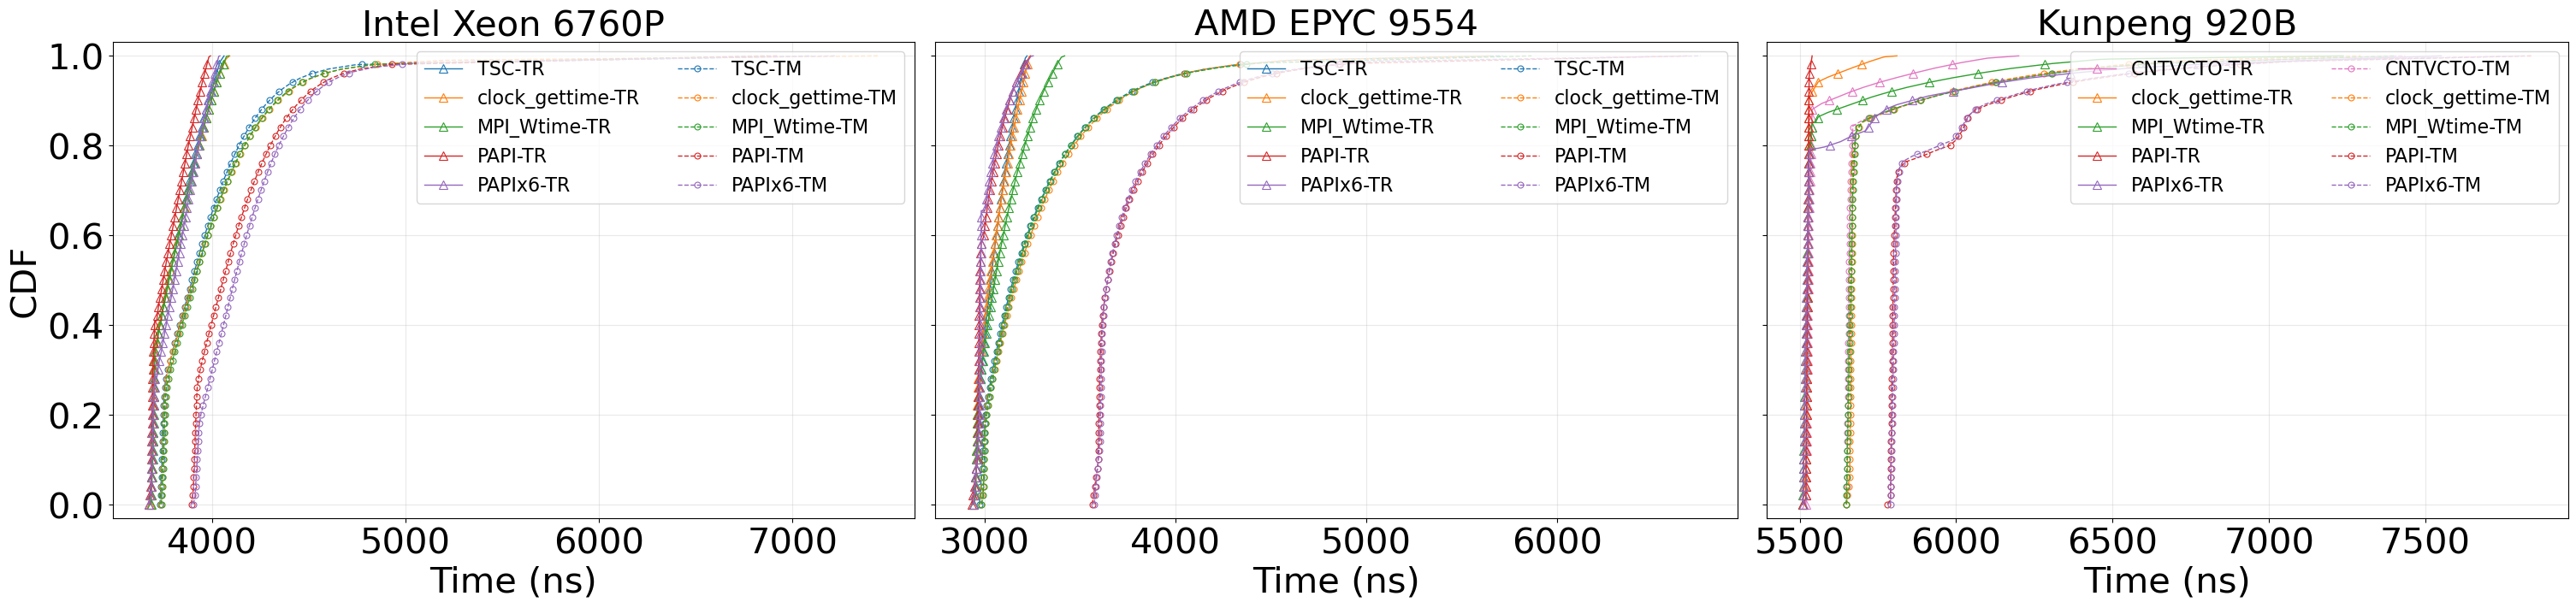

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=2048  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=9273.78 ns  tr_median=9082.33 ns
host=cgnr6760pn2 timer=cgt  tm_median=9197.08 ns  tr_median=8915.60 ns
host=cgnr6760pn2 timer=wtime  tm_median=8594.44 ns  tr_median=7867.72 ns
host=cgnr6760pn2 timer=papi  tm_median=8016.76 ns  tr_median=7436.69 ns
host=cgnr6760pn2 timer=papix6  tm_median=8167.71 ns  tr_median=7555.82 ns
host=camd9554n1 timer=tsc  tm_median=7550.66 ns  tr_median=7368.64 ns
host=camd9554n1 timer=cgt  tm_median=7550.07 ns  tr_median=7488.53 ns
host=camd9554n1 timer=wtime  tm_median=7568.68 ns  tr_median=7440.75 ns
host=camd9554n1 timer=papi  tm_median=7504.79 ns  tr_median=6730.19 ns
host=camd9554n1 timer=papix6  tm_median=7482.08 ns  tr_median=6779.74 ns
host=c920bn3 timer=cntvcto  tm_median=11307.68 ns  tr_median=11085.69 ns
host=c9

/astrum/home/hpchzy/code/TacVar/stencil/plots_0630_gs2d5p_dsub/gs2d5p_cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2_np64_size2048_ratio0.5_tm_tr_by_host.png


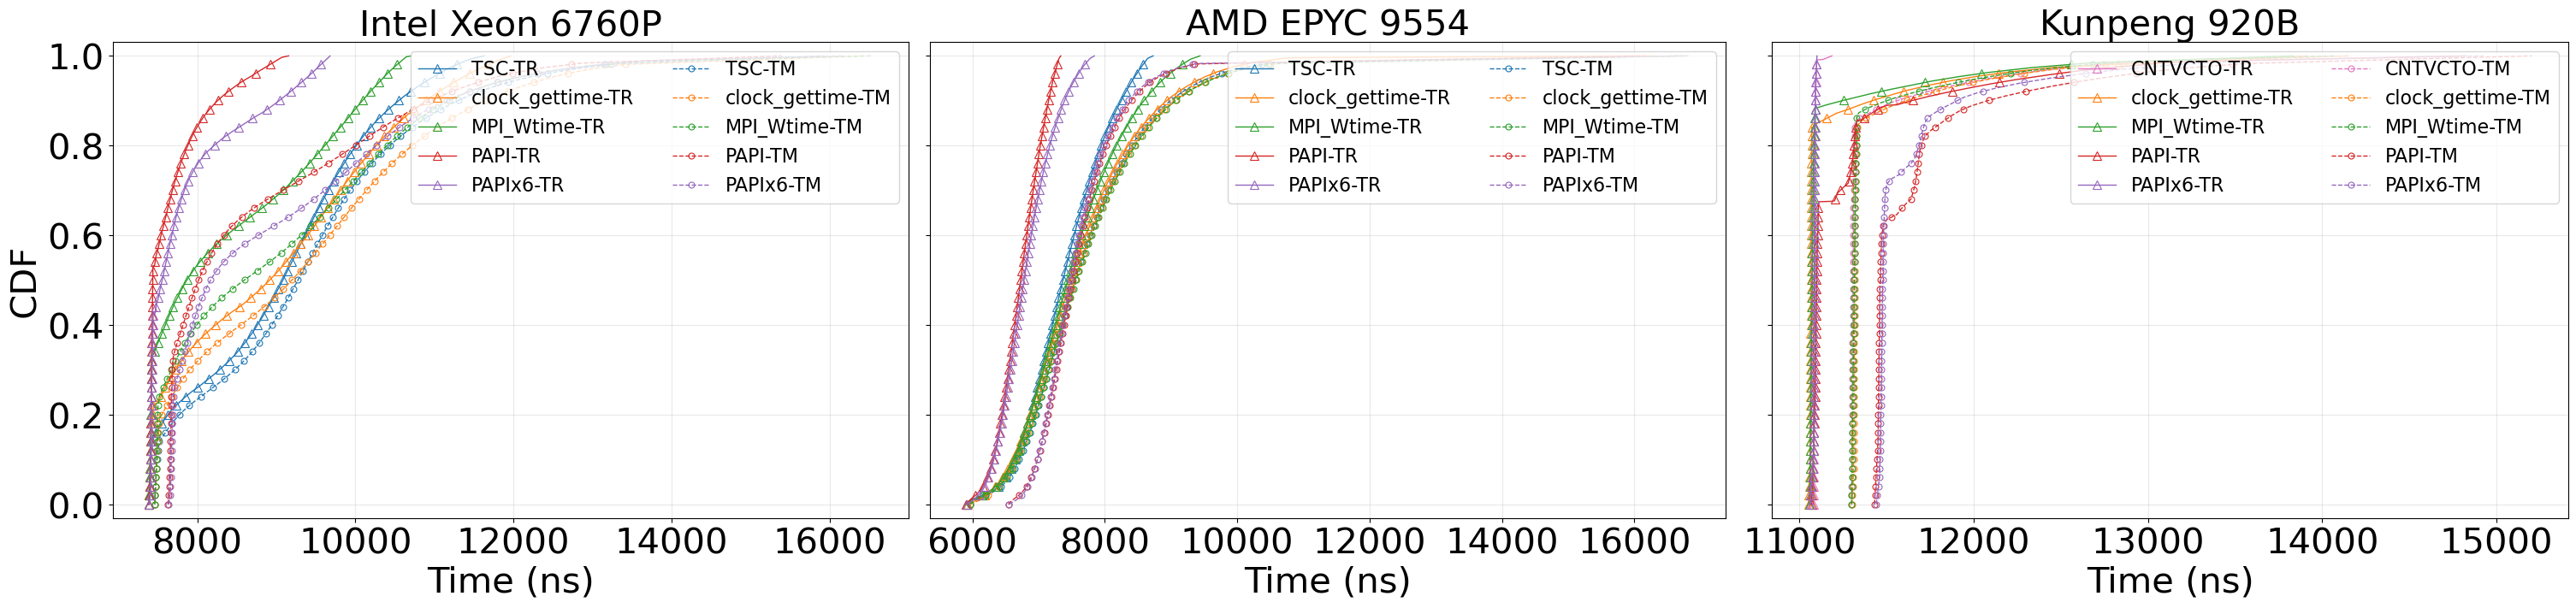

In [13]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
